# Income Spending Survey – Analysis


In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = '../data/responses.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError('CSV not found. Run: python export_to_csv.py')

df = pd.read_csv(csv_path)
df.head()


,age,gender,total_income,utilities,entertainment,school_fees,shopping,healthcare,total_expenses,savings_estimate
0,30,Female,8000.0,500.0,1000.0,1500.0,2000.0,2000.0,7000.0,1000.0
1,50,Male,10500.0,1000.0,700.0,1500.0,2000.0,4000.0,9200.0,1300.0
2,28,Female,8000.0,1000.0,1200.0,1900.0,600.0,2500.0,7200.0,800.0
3,20,Male,4500.0,0.0,0.0,2000.0,0.0,200.0,2200.0,2300.0
4,30,Male,7000.0,2000.0,0.0,0.0,730.0,3900.0,6630.0,370.0


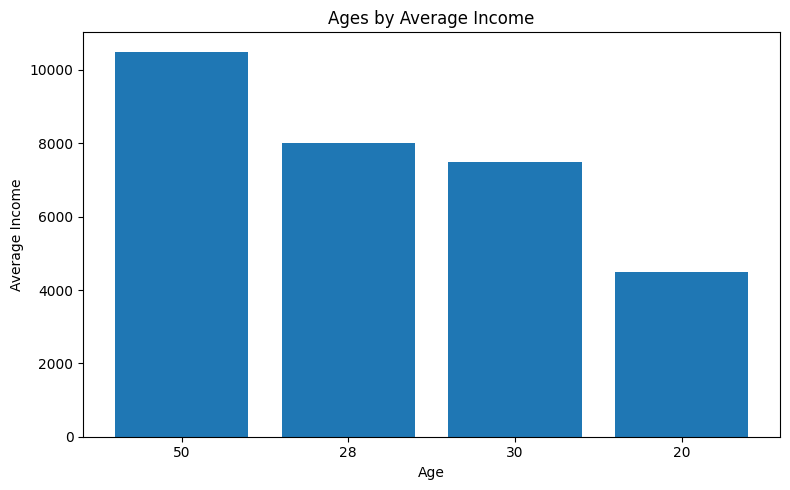

In [30]:
# Visualization 1: Ages with the highest income (top 10 ages by average income)
age_income = (
    df.groupby('age', as_index=False)['total_income']
      .mean()
      .sort_values('total_income', ascending=False)
      .head(10)
)

plt.figure(figsize=(8,5))
plt.bar(age_income['age'].astype(str), age_income['total_income'])
plt.title('Ages by Average Income')
plt.xlabel('Age')
plt.ylabel('Average Income')
plt.tight_layout()

os.makedirs('../static/charts', exist_ok=True)
plt.savefig('../static/charts/top_ages_income.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


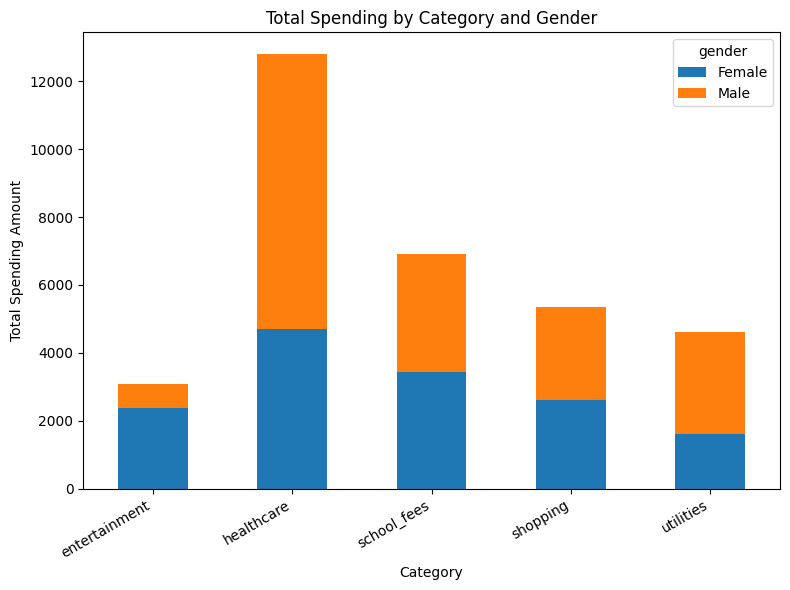

In [20]:
# Visualization 2: Gender distribution across spending categories (total spending by category, stacked by gender)
categories = ['utilities','entertainment','school_fees','shopping','healthcare']
long = df.melt(id_vars=['gender'], value_vars=categories, var_name='category', value_name='amount')
pivot = long.pivot_table(index='category', columns='gender', values='amount', aggfunc='sum').fillna(0)

ax = pivot.plot(kind='bar', stacked=True, figsize=(8,6))
ax.set_title('Total Spending by Category and Gender')
ax.set_xlabel('Category')
ax.set_ylabel('Total Spending Amount')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../static/charts/gender_spend_by_category.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
